# 🧬 Bioinformatics Lab Exercises: DNA/RNA/Protein Sequences

This notebook contains 5 exercises to practice sequence operations, translation, reverse translation, and simple data analysis using Biotite and Python.

## Imports and Setup

In [1]:
import biotite.sequence.io.fasta as fasta
from biotite.sequence import NucleotideSequence, ProteinSequence
import matplotlib.pyplot as plt
import numpy as np
import random

## Exercise 1: Basic Sequence Operations
**Objectives:**
- Load a FASTA file
- Compute nucleotide frequencies and GC content
- Translate DNA to protein

In [2]:
# Example FASTA sequences
fasta_content = ">Seq1\nATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG\n" +\
                ">Seq2\nGGGCCCAAATTTGGGCCCAGATATATATATGGGCCCTTT\n"

# Write to a file for demonstration
with open("exercise1.fasta", "w") as f:
    f.write(fasta_content)

# Read FASTA
fasta_file = fasta.FastaFile.read("exercise1.fasta")

# Compute nucleotide frequencies and GC content
sequences = fasta.get_sequences(fasta_file)

# calculate these

for seq_id, seq in sequences.items():
    nucleotide_counts = {'A': 0, 'C': 0, 'G': 0, 'T': 0}
    for nucleotide in seq:
        nucleotide_counts[nucleotide] += 1
    GC_content = 100.0 * (nucleotide_counts['G'] + nucleotide_counts['C']) / len(seq)

    # printing at the end
    print(f"Nucleotide counts: {nucleotide_counts}")
    print(f"GC content: {GC_content}")

Nucleotide counts: {'A': 9, 'C': 8, 'G': 14, 'T': 8}
GC content: 56.41025641025641
Nucleotide counts: {'A': 9, 'C': 9, 'G': 10, 'T': 11}
GC content: 48.717948717948715


## Exercise 2: Reverse Translation (Protein -> DNA)
**Objectives:**
- Implement a function to generate a DNA sequence from a protein sequence
- Use a codon table

In [3]:
from typing import Optional, Union, List
from math import prod
from itertools import islice, product

# Simplified codon table amino acids : codons
codon_table = {
    'A': ['GCT','GCC','GCA','GCG'],
    'C': ['TGT','TGC'],
    'D': ['GAT','GAC'],
    'E': ['GAA','GAG'],
    'F': ['TTT','TTC'],
    'G': ['GGT','GGC','GGA','GGG'],
    'H': ['CAT','CAC'],
    'I': ['ATT','ATC','ATA'],
    'K': ['AAA','AAG'],
    'L': ['TTA','TTG','CTT','CTC','CTA','CTG'],
    'M': ['ATG'],
    'N': ['AAT','AAC'],
    'P': ['CCT','CCC','CCA','CCG'],
    'Q': ['CAA','CAG'],
    'R': ['CGT','CGC','CGA','CGG','AGA','AGG'],
    'S': ['TCT','TCC','TCA','TCG','AGT','AGC'],
    'T': ['ACT','ACC','ACA','ACG'],
    'V': ['GTT','GTC','GTA','GTG'],
    'W': ['TGG'],
    'Y': ['TAT','TAC'],
    '*': ['TAA','TAG','TGA']  # Stop codons
}

# Implement reverse translation function
# Optionally, specify the number of sequences to generate
# What is the maximal number of sequences that can be generated from a protein sequence?

def max_reverse_translation_sequences(
    protein_seq: ProteinSequence,
    codon_table: dict = codon_table
) -> int:
    """
    Calculate maximal number of DNA sequences that can encode the protein.
    """
    seq_str = str(protein_seq).upper()

    counts = []
    for aa in seq_str:
        if aa not in codon_table:
            raise ValueError(f"Unsupported amino acid symbol: {aa!r}")
        counts.append(len(codon_table[aa]))

    return prod(counts)

def reverse_translate(protein_seq: ProteinSequence, codon_table: dict = codon_table, sequence_num: Optional[int] = None) -> NucleotideSequence:
    """S
    Reverse translate a protein sequence into DNA candidate(s)
    """
    seq_str = str(protein_seq).upper()

    # Validate symbols and build codon choices per position
    codon_choices = []
    for aa in seq_str:
        if aa not in codon_table:
            raise ValueError(f"Unsupported amino acid symbol: {aa!r}")
        
        codons = codon_table[aa]
        if len(codons) == 0:
            raise ValueError(f"No codons defined for amino acid: {aa!r}")
        codon_choices.append(codons)
        
    if sequence_num is None:
        # Deterministic single candidate: take first codon at each position
        dna_str = "".join(codons[0] for codons in codon_choices)
        return NucleotideSequence(dna_str)

    if sequence_num <= 0:
        return []
    
    # Enumerate combinations lazily (important when the total count is huge)
    candidates = []
    for codon_tuple in islice(product(*codon_choices), sequence_num):
        dna_str = "".join(codon_tuple)
        candidates.append(NucleotideSequence(dna_str))

    return candidates
    


# Example protein sequence
prot = ProteinSequence('MGR*')
dna_candidate = reverse_translate(prot, codon_table, 10)
print(f"Protein: {prot}")

for dna in dna_candidate:
    print(f"Reverse-translated DNA: {dna}")

Protein: MGR*
Reverse-translated DNA: ATGGGTCGTTAA
Reverse-translated DNA: ATGGGTCGTTAG
Reverse-translated DNA: ATGGGTCGTTGA
Reverse-translated DNA: ATGGGTCGCTAA
Reverse-translated DNA: ATGGGTCGCTAG
Reverse-translated DNA: ATGGGTCGCTGA
Reverse-translated DNA: ATGGGTCGATAA
Reverse-translated DNA: ATGGGTCGATAG
Reverse-translated DNA: ATGGGTCGATGA
Reverse-translated DNA: ATGGGTCGGTAA


## Exercise 3: mRNA Exon Sequence Retrieval (Mock Data)
**Objectives:**
- Simulate mRNA exons
- Concatenate exons and translate

In [4]:
from biotite.sequence import CodonTable
reverse_codon_table = {i: k for k, v in codon_table.items() for i in v}
new_codon_table = CodonTable(
    codon_dict = reverse_codon_table,
    starts=['ATG']
)

# Mock sequence and exons
full_sequence = 'ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAGATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAGATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG'
exon_indices = [[0,15], [21,27], [31,37]]


# Concatenate exons and translate to protein
exon_seq = "".join(full_sequence[start:end] for start, end in exon_indices)
print(exon_seq)
mrna = NucleotideSequence(exon_seq)
protein_seq = mrna.translate(codon_table=new_codon_table, met_start=True)
print(f"mRNA sequence: {mrna}")
print(len(mrna))
print(f"Translated protein: {protein_seq[0]}")

ATGGCCATTGTAATGTGAAAGCCCGAT
mRNA sequence: ATGGCCATTGTAATGTGAAAGCCCGAT
27
Translated protein: [ProteinSequence("MAIVM*"), ProteinSequence("M*")]


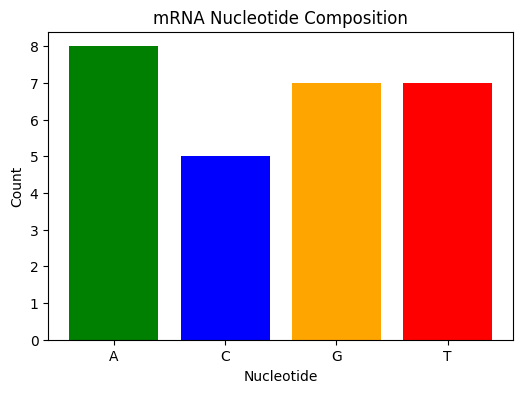

In [5]:
import matplotlib.pyplot as plt

# Visualization: show nucleotide composition of mRNA as barplot with color=['green','blue','orange','red']
labels = ['A', 'C', 'G', 'T']
counts = {nt: str(mrna).count(nt) for nt in labels}

plt.figure(figsize=(6, 4))
plt.bar(labels, [counts[nt] for nt in labels], color=['green', 'blue', 'orange', 'red'])
plt.title('mRNA Nucleotide Composition')
plt.xlabel('Nucleotide')
plt.ylabel('Count')
plt.show()

## Optional Exercise 3b: Fetch Real Gene Exons from NCBI
**Objectives:**
- Use NCBI Entrez API to retrieve gene sequence
- Extract exons/CDS and translate to protein

In [ ]:
import biotite.database.entrez as entrez
import biotite.sequence.io.genbank as gb


def fetch_gene_cds(
    gene_name: str,
    organism: str = "Homo sapiens",
    number: int = 1,
) -> Optional[str]:
    """
    Fetch a nucleotide GenBank record from NCBI Entrez using Biotite and return
    concatenated CDS nucleotide sequence(s) from the first hit.
    """

    # Build Entrez query
    query = (
        entrez.SimpleQuery(gene_name, "Gene Name")
        & entrez.SimpleQuery(organism, "Organism")
    )

    # Search UIDs
    uids = entrez.search(query, db_name="Nucleotide", number=number)

    if not uids:
        print("Gene not found.")
        return None

    uid = uids[0]

    # Fetch GenBank
    gb_io = entrez.fetch_single_file([uid], None, "Nucleotide", "gb", ret_mode="text")

    # Parse GenBank
    gb_file = gb.GenBankFile.read(gb_io)
    seq = gb.get_sequence(gb_file)
    annotation = gb.get_annotation(gb_file)

    # Extract CDS fragments
    cds_fragments = []
    for feature in annotation:
        if feature.key != "CDS":
            continue

        for loc in feature.locs:
            start = loc.first - 1
            stop = loc.last
            frag = seq[start:stop]
            cds_fragments.append(str(frag))

    if not cds_fragments:
        print("No CDS/exons found for this gene.")
        return None

    return "".join(cds_fragments)

# Obtain mRNA sequence for BRCA1 gene and translate to protein sequence
gene_name = "BRCA1"
cds_fragments = fetch_gene_cds(gene_name)
print(cds_fragments)

ValueError: Unknown field identifier 'Gene'

## Exercise 4: Translation Efficiency Simulation
**Objectives:**
- Calculate translation time based on codon availability
- Determine mean translation time for a protein

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import ndarray

# Example tRNA abundance table (arbitrary values)
tRNA_table = {
    'GCT': 5, 'GCC': 10, 'GCA': 4, 'GCG': 8,
    'ATG': 15, 'CGT': 10,
    'GGT': 8, 'GGC': 12, 'GGA': 6, 'GGG': 9,
    'TAA': 0, 'TAG': 0, 'TGA': 0  # stop codons
}

sequence = NucleotideSequence('ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG')
# Translation speed = 1 / tRNA abundance
# Translation time   = 1 / speed proxy = 1 / abundance
def calculate_translation_time(nucleotide_seq: str, tRNA_table: dict = tRNA_table) -> float:
    """Calculate translation time for a nucleotide sequence."""
    if len(nucleotide_seq) % 3 != 0:
        raise ValueError("Sequence length must be divisible by 3.")

    total_time = 0.0

    for i in range(0, len(nucleotide_seq), 3):
        codon = nucleotide_seq[i:i+3]

        if codon not in tRNA_table:
            raise ValueError(f"Codon {codon} not found in tRNA table.")

        abundance = tRNA_table[codon]

        if abundance <= 0:
            raise ValueError(f"Codon {codon} has zero or invalid tRNA abundance.")

        total_time += 1.0 / abundance

    return total_time


def calculate_per_residue_mean_translation_time(
    protein_seq: str,
    codon_table: dict = codon_table,
    tRNA_table: dict = tRNA_table
) -> ndarray:
    """
    Calculate per-residue mean translation time for a protein sequence
    as mean over all source codons for each amino acid.
    """
    times = []

    for aa in protein_seq:
        if aa not in codon_table:
            raise ValueError(f"Amino acid {aa} not found in codon table.")

        codons = codon_table[aa]

        codon_times = []
        for codon in codons:
            if codon not in tRNA_table:
                continue

            abundance = tRNA_table[codon]
            if abundance > 0:
                codon_times.append(1.0 / abundance)

        if len(codon_times) == 0:
            times.append(np.nan)  # no data available for this residue
        else:
            times.append(np.mean(codon_times))

    return np.array(times)


translation_times = calculate_per_residue_mean_translation_time(prot)
print(f"Per-residue translation times: {translation_times}")
print(f"Mean translation time: {translation_times.mean():.2f}")

# Implement barplot showing translation time per amino acid
positions = np.arange(1, len(translation_times) + 1)

plt.figure(figsize=(8, 4))
plt.bar(positions, translation_times)
plt.xlabel('Residue position')
plt.ylabel('Translation time')
plt.title('Translation Time per Amino Acid')
plt.xticks(positions)
plt.show()

## Exercise 5: Sequence Analysis Pipeline
**Objectives:**
- Integrate previous steps
- Visualize composition and translation efficiency

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import ndarray
from biotite.sequence import ProteinSequence, NucleotideSequence

# Input: protein sequence
protein_input = ProteinSequence('MGRMGR')

# Reverse translate
dna_seq = reverse_translate(protein_input)
print(f"DNA candidate: {dna_seq}")

# Translate back to protein (frame 0)
protein_check = dna_seq.translate(complete=True)   # if complete=False, translation does not require a terminal stop codon
print(f"Translated back: {protein_check}")


# Propose a sequence with the fastest and the slowest translation time
def get_fastest_and_slowest_sequences(
    protein_seq: str,
    codon_table: dict = codon_table,
    tRNA_table: dict = tRNA_table
) -> tuple[NucleotideSequence, NucleotideSequence]:
    """
    For each amino acid, choose:
    - fastest codon: highest tRNA abundance
    - slowest codon: lowest positive tRNA abundance
    """
    fastest_codons = []
    slowest_codons = []

    for aa in str(protein_seq):
        if aa not in codon_table:
            raise ValueError(f"Amino acid {aa} not found in codon_table")

        valid_codons = [
            codon for codon in codon_table[aa]
            if codon in tRNA_table and tRNA_table[codon] > 0
        ]

        if len(valid_codons) == 0:
            raise ValueError(
                f"No codons with positive tRNA abundance for amino acid {aa}. "
                f"Extend tRNA_table or change the protein sequence."
            )

        fastest_codon = max(valid_codons, key=lambda c: tRNA_table[c])
        slowest_codon = min(valid_codons, key=lambda c: tRNA_table[c])

        fastest_codons.append(fastest_codon)
        slowest_codons.append(slowest_codon)

    return (
        NucleotideSequence("".join(fastest_codons)),
        NucleotideSequence("".join(slowest_codons)),
    )


fastest_translation_sequence, slowest_translation_sequence = get_fastest_and_slowest_sequences(protein_input)

print(f"Fastest translation DNA sequence: {fastest_translation_sequence}")
print(f"Slowest translation DNA sequence: {slowest_translation_sequence}")


# Implement the function calculating the per-residue translation time starting from nucleotide sequence
def per_res_translation_time(nucleotide_seq: str, tRNA_table: dict = tRNA_table) -> ndarray:
    """Calculate per-residue translation time for a nucleotide sequence."""
    nucleotide_seq = str(nucleotide_seq)

    if len(nucleotide_seq) % 3 != 0:
        raise ValueError("Sequence length must be divisible by 3.")

    times = []
    for i in range(0, len(nucleotide_seq), 3):
        codon = nucleotide_seq[i:i+3]

        if codon not in tRNA_table:
            raise ValueError(f"Codon {codon} not found in tRNA_table.")

        abundance = tRNA_table[codon]
        if abundance <= 0:
            raise ValueError(f"Codon {codon} has non-positive tRNA abundance.")

        times.append(1.0 / abundance)

    return np.array(times, dtype=float)


# Calculate the translation time for the proposed sequences
fastest_translation_time = per_res_translation_time(fastest_translation_sequence)
slowest_translation_time = per_res_translation_time(slowest_translation_sequence)

print(f"Per-residue translation time (fastest): {fastest_translation_time}")
print(f"Per-residue translation time (slowest): {slowest_translation_time}")


# Helper function: nucleotide composition
def nucleotide_counts(seq: str) -> dict:
    seq = str(seq)
    return {nt: seq.count(nt) for nt in ['A', 'C', 'G', 'T']}


fast_counts = nucleotide_counts(fastest_translation_sequence)
slow_counts = nucleotide_counts(slowest_translation_sequence)

# Cumulative translation time as function of residue number
fast_cumulative = np.cumsum(fastest_translation_time)
slow_cumulative = np.cumsum(slowest_translation_time)
residue_positions = np.arange(1, len(fastest_translation_time) + 1)


# Visualization
# Create figure with subplots: 2 plots in left column, 1 larger plot in right panel
fig = plt.figure(figsize=(12, 8))

# Left column: two subplots stacked vertically
ax1 = plt.subplot2grid((2, 2), (0, 0))  # Top left
ax2 = plt.subplot2grid((2, 2), (1, 0))  # Bottom left

# Right panel: one larger subplot spanning both rows
ax3 = plt.subplot2grid((2, 2), (0, 1), rowspan=2)  # Right side, spans both rows

# ax1 - barplot of nucleotide composition of the fastest translation sequence
labels = ['A', 'C', 'G', 'T']
colors = ['green', 'blue', 'orange', 'red']
ax1.bar(labels, [fast_counts[nt] for nt in labels], color=colors)
ax1.set_xlabel('Nucleotide')
ax1.set_ylabel('Count')
ax1.set_title('Nucleotide Composition - Fastest Translation Sequence')

# ax2 - barplot of nucleotide composition of the slowest translation sequence
ax2.bar(labels, [slow_counts[nt] for nt in labels], color=colors)
ax2.set_xlabel('Nucleotide')
ax2.set_ylabel('Count')
ax2.set_title('Nucleotide Composition - Slowest Translation Sequence')

# ax3 - line plot of total translation time as a function of the number of residues
ax3.plot(residue_positions, fast_cumulative, marker='o', label='Fastest translation sequence')
ax3.plot(residue_positions, slow_cumulative, marker='o', label='Slowest translation sequence')
ax3.set_xlabel('Number of Residues')
ax3.set_ylabel('Cumulative Translation Time')
ax3.set_title('Total Translation Time vs Number of Residues')
ax3.legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()